## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11391 entries, 0 to 11390
Data columns (total 57 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   CashAndCashEquivalents           11391 non-null  float64       
 1   CurrentDebt                      11391 non-null  float64       
 2   LongTermDebt                     11391 non-null  float64       
 3   TotalDebt                        11391 non-null  float64       
 4   StockholdersEquity               11391 non-null  float64       
 5   TotalAssets                      11391 non-null  float64       
 6   CurrentAssets                    11391 non-null  float64       
 7   CurrentLiabilities               11391 non-null  float64       
 8   OperatingCashFlow_TTM            11391 non-null  float64       
 9   InvestingCashFlow_TTM            11391 non-null  float64       
 10  FinancingCashFlow_TTM            11391 non-null  float64  

## Feature Engineering

Sección para crear variables en la fase de modelado. 
La mayor parte de las variables fue creada en la fase de transformación.

In [3]:
# Calcular las aceleraciones netas (Momento - Tendencia) para variables de crecimiento.
# Una vez calculadas, se eliminan las variables trimestrales (reemplazar=True)
variables_de_crecimiento = ['Revenue_QoQ', 'Ebitda_QoQ', 'Fcf_QoQ', 'CapEx_QoQ']
df = calcular_acceleration_features(df, variables_de_crecimiento, reemplazar= True)

In [4]:
# Variable flag: empresas gigantes
df['IsMegaCap'] = (df['MarketCap'] > 200).astype(int)

In [5]:
# Sectores poco significativos: se agrupan en la categoria "Other"
# Se saltea en la versión actual
#sectores_importantes = ['InformationTechnology', 'Energy']

#df['Sector'] = np.where(df['Sector'].isin(sectores_importantes), df['Sector'], 'Other')

# Se vuelve a convertir en category
#df['Sector'] = df['Sector'].astype('category')

# Modelo de ensamblado de árboles RandomForest

In [6]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores
cols_financieras = obtener_cols_financieras()
variables_no_significativas = [

]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Ticker y fecha
    'Ticker',
    'Date',
    # Totales del mercado
    'TotalMarketAssets',
    'TotalMarketRevenue',
    # Variables que dependen del precio (posibles labels)
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda',
    'MarketCap',
    'EnterpriseValue',
    'Open',
    'Close' # no usar como label, corresponden los precios Open
    ]

# Se define la variable objetivo y las variables predictoras
label = 'Open'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.4755


In [7]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: -12.6481 ± 25.6730


In [8]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
26,cat__Industry,0.528905
0,num__Volume,0.289432
18,num__RelativeAssets_log,0.045927
6,num__DebtToEquity,0.037777
1,num__YearsSinceAdded,0.032562
19,num__RelativeRevenue_log,0.028697
25,cat__Sector,0.008107
16,num__QuarterlyVariance,0.005476
5,num__ReturnOnAssets,0.005314
14,num__CapExToRevenue,0.004964


In [9]:
feature_importance_df.tail(10)

,feature,importance
7,num__CurrentRatio,1.775923e-05
2,num__OperatingMargins,1.158381e-05
4,num__ReturnOnEquity,9.499379e-06
8,num__Revenue_YoY,2.273569e-06
20,num__Revenue_Acceleration,1.736714e-06
15,num__QuarterlyReturn,6.221710e-07
9,num__Ebitda_YoY,5.743236e-07
11,num__CapEx_YoY,5.539180e-07
10,num__Fcf_YoY,4.704651e-07
22,num__Fcf_Acceleration,2.673418e-07


In [10]:
X.describe()

,Volume,YearsSinceAdded,OperatingMargins,ProfitMargins,ReturnOnEquity,ReturnOnAssets,DebtToEquity,CurrentRatio,Revenue_YoY,Ebitda_YoY,...,QuarterlyReturn,QuarterlyVariance,MarketCovariance,RelativeAssets_log,RelativeRevenue_log,Revenue_Acceleration,Ebitda_Acceleration,Fcf_Acceleration,CapEx_Acceleration,IsMegaCap
count,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,...,11391.000000,11391.000000,11391.000000,1.139100e+04,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000,11391.000000
mean,206.410105,14.987885,0.153942,0.097101,0.423741,0.126722,1.297985,1.609305,0.106442,0.169909,...,0.034999,0.025811,0.001912,1.214100e-03,0.001496,-0.073662,-0.102625,-0.078328,0.176185,0.054517
std,246.893866,20.019991,0.121408,0.104855,0.564727,0.163529,1.344268,1.034077,0.182474,0.489332,...,0.157296,0.026596,0.004351,1.482628e-03,0.001530,0.152418,0.423865,0.924120,0.509497,0.227044
min,0.000200,0.000000,-0.296845,-0.238389,-1.065120,-0.306032,-3.402263,-2.234085,-0.450499,-1.162069,...,-0.573975,-0.029573,-0.013324,1.518358e-08,0.000000,-0.714510,-2.048969,-3.267726,-2.253525,0.000000
25%,44.149050,0.000000,0.077296,0.044083,0.098922,0.032543,0.434003,1.021387,0.009931,-0.051595,...,-0.059543,0.007569,-0.000317,2.431850e-04,0.000434,-0.119103,-0.232772,-0.315247,-0.074492,0.000000
50%,103.240100,7.000000,0.145530,0.078080,0.203747,0.069811,0.801286,1.399400,0.082501,0.114307,...,0.034917,0.016971,0.001563,5.603068e-04,0.000931,-0.051218,-0.057947,0.021997,0.094426,0.000000
75%,257.951700,24.000000,0.201730,0.137593,0.476114,0.144367,1.640760,1.981893,0.163264,0.315997,...,0.111642,0.035631,0.003996,1.499792e-03,0.001783,0.006056,0.088599,0.324826,0.319078,0.000000
max,899.762300,69.000000,0.576490,0.418274,1.609023,0.494629,5.266144,4.863418,0.624162,1.424820,...,0.626435,0.120106,0.017146,5.273490e-03,0.005837,0.736873,1.981227,3.264812,2.479983,1.000000


## Aplicacion del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [11]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 379 tickers, residuo medio global: 736.4121
Underprediction: 105 tickers, residuo medio global: -134.4453


In [12]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker    Predicted    Observed    Residuals      Cluster  PercentError
CTA-PB 53326.114508   67.250000 53258.864508 PositiveBias  7.919534e+04
   GHC 31070.250963 1098.959961 29971.291002 PositiveBias  2.727241e+03
 RSTRF 21391.862467   79.589996 21312.272471 PositiveBias  2.677758e+04
  CPHI 20463.643821    0.760000 20462.883821 PositiveBias  2.692485e+06
   NVR 24873.977240 6135.000000 18738.977240 PositiveBias  3.054438e+02


In [13]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,QuarterlyReturn,QuarterlyVariance,MarketCovariance,RelativeAssets_log,RelativeRevenue_log,Revenue_Acceleration,Ebitda_Acceleration,Fcf_Acceleration,CapEx_Acceleration,IsMegaCap
0,CTA-PB,53326.114508,67.250000,53258.864508,PositiveBias,7.919534e+04,1.964000,1.674000,1.682000,3.356000,...,0.005324,0.001366,-0.000212,0.002140,1.229286e-03,-0.034690,-0.017712,-0.246538,0.086453,0
1,GHC,31070.250963,1098.959961,29971.291002,PositiveBias,2.727241e+03,0.135676,0.107098,0.714884,1.246410,...,0.055062,0.005723,0.002678,0.000410,3.424772e-04,-0.022676,-0.679542,0.296314,0.040037,0
2,RSTRF,21391.862467,79.589996,21312.272471,PositiveBias,2.677758e+04,1.012000,0.075000,13.228000,15.706000,...,0.179866,0.030999,0.003863,0.001247,6.357559e-04,-0.103733,0.012601,-0.012630,0.371098,0
3,CPHI,20463.643821,0.760000,20462.883821,PositiveBias,2.692485e+06,0.000168,0.003692,0.000164,0.003856,...,0.433962,0.120106,0.017146,0.000002,2.744553e-07,0.082249,-0.368011,1.567612,-0.031544,0
4,NVR,24873.977240,6135.000000,18738.977240,PositiveBias,3.054438e+02,1.682067,0.141190,0.908662,1.049852,...,-0.167690,0.016352,-0.001650,0.000280,6.749713e-04,0.015825,0.032320,0.323577,-0.069408,0


## Explicabilidad del Modelo (SHAP)

In [14]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'MSFT'

--- Explicación de la predicción para: MSFT ---


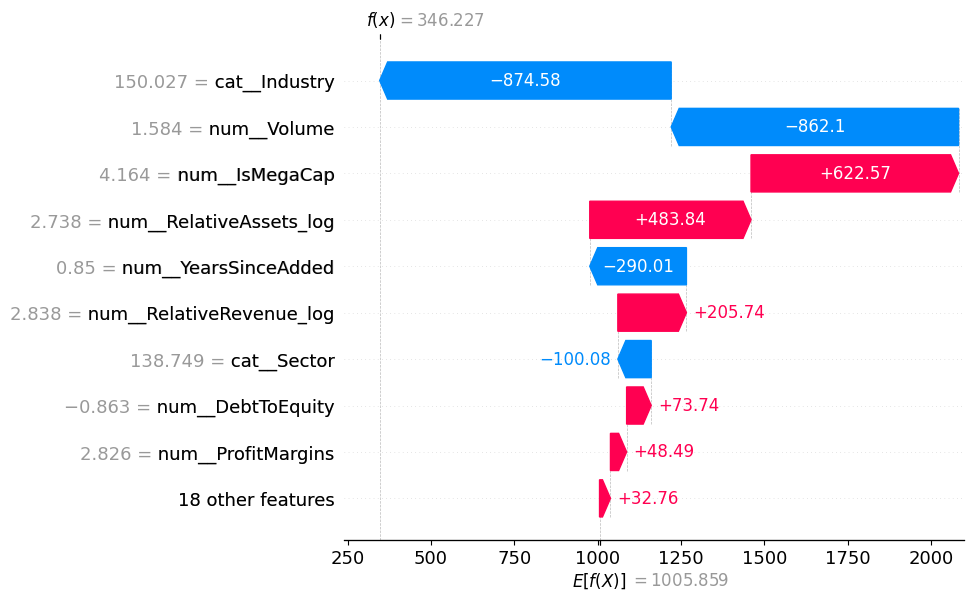

In [15]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiperparámetros

In [16]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)